# Deep Ensemble Classifier for Elasticity Failure Maps

This notebook uses `DeepEnsembleClassifier` on a two-parameter failure map
motivated by notch-driven stress concentration in elasticity.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == 'sciml':
    PROJECT = ROOT.parents[1]
else:
    PROJECT = ROOT
SRC = PROJECT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

In [2]:
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset

from deepuq.methods import DeepEnsembleClassifier
from deepuq.models import MLP

torch.manual_seed(5)

## Scientific setup

We consider a simplified elastic design map with two parameters:

- $P$: normalized remote load,
- $\alpha$: notch sharpness.

A surrogate maximum stress is defined as

$$
\sigma_{\max} = P (1 + 2\alpha),
$$

and failure is triggered when $\sigma_{\max}$ exceeds a critical threshold.
The ensemble should have largest disagreement near the decision boundary.

In [3]:
def stress_surrogate(load, alpha):
    return load * (1.0 + 2.0 * alpha)

def sample_classification(n, *, ood=False):
    if ood:
        load = torch.rand(n) * 0.5 + 1.0
        alpha = torch.rand(n) * 2.0 + 3.0
    else:
        load = torch.rand(n) * 0.8 + 0.2
        alpha = torch.rand(n) * 2.0 + 1.0
    label = (stress_surrogate(load, alpha) > 4.0).long()
    return torch.stack([load, alpha], dim=1), label

In [4]:
x_train, y_train = sample_classification(600)
x_test, y_test = sample_classification(200)
x_ood, y_ood = sample_classification(200, ood=True)
loader = DataLoader(TensorDataset(x_train, y_train), batch_size=64, shuffle=True)
classifier = DeepEnsembleClassifier([MLP(2, [32, 32], 2, p_drop=0.0) for _ in range(5)])
classifier.fit(loader, epochs=80, lr=2e-3, seed=19)

DeepEnsembleClassifier(
  (models): ModuleList(
    (0-4): 5 x MLP(
      (net): Sequential(
        (0): Linear(in_features=2, out_features=32, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.0, inplace=False)
        (3): Linear(in_features=32, out_features=32, bias=True)
        (4): ReLU()
        (5): Dropout(p=0.0, inplace=False)
        (6): Linear(in_features=32, out_features=2, bias=True)
      )
    )
  )
)

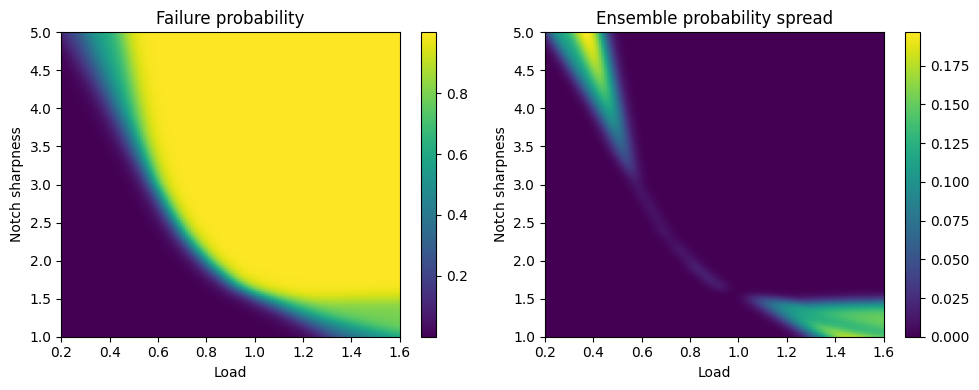

In [5]:
grid_load = torch.linspace(0.2, 1.6, 120)
grid_alpha = torch.linspace(1.0, 5.0, 120)
LL, AA = torch.meshgrid(grid_load, grid_alpha, indexing='ij')
grid = torch.stack([LL.reshape(-1), AA.reshape(-1)], dim=1)
uq = classifier.predict_uq(grid)
probs = uq.probs[:, 1].reshape(120, 120)
spread = uq.probs_var[:, 1].reshape(120, 120)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, arr, title in zip(axes, [probs, spread], ['Failure probability', 'Ensemble probability spread']):
    im = ax.imshow(arr.T, origin='lower', aspect='auto', extent=[0.2, 1.6, 1.0, 5.0])
    ax.set_xlabel('Load')
    ax.set_ylabel('Notch sharpness')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
plt.tight_layout()